In [66]:
from binary_optimizer import *
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Running the quantum expected value function algorithm
This notebook will walk through how to use the code, as it is on June 25 2024, to compute the expected value function with a quantum algorithm. The two stage objective function has the form 
$$ \min_x o(x) := f(x) + \mathbb{E}_\xi [Q(x,\xi)]$$
where $\phi(x) \equiv \mathbb{E}_\xi [Q(x,\xi)]$ is computed on the quantum computer.

We will focus on a problem inspired by the power grid, with $n_y$ wind turbines labeled from $0$ to $n_y-1$ and a single gas generator $x$. Each wind turbine can be 'off' or 'on', conditional on whether the wind is blowing at that turbine's location. If $\xi$ is the random variable, and $\xi_i \in {0,1}$ is $0$ when the wind does _not_ blow and $1$ when it does at turbine $i$. If total power demand is $d$, the cost of using a resource is $c$, and $r$ represents the penalty of not satisfying demand, we get the objective function:

$$ \min_{x \in \mathbb{Z}_{\geq 0}} o(x) := c_xx + \mathbb{E}_\xi[Q(x,\xi)] $$

$$ Q(x,\xi) = \min_{y \in \{0,1\}^{n_y}} \sum_{i=0}^{n_y-1} c_{y,i} y_i  + c_r r$$

$$ \sum_{i=0}^{n_y-1} y_i + x = d-r $$

$$ y_i \leq \xi_i \; \forall i $$

To run through this example, we will choose 4 wind turbines that each have their own cost, sorted as the cheapest to most expensive, left to right (right to left in Qiskit order). We assume that $\xi$ is independently identically distributed (uniform distribution). We create the object `BinaryNestedOptimizer` from the `binary_optimizer` module to host our example problem. 

In [200]:
# number of variables
n_y = 4
n_xi = 4
n_x = 1
n = n_y + n_xi + n_x
d = n_y

# costs
c_x = [3.,]
c_y = [0.4, 0.5, 0.7, 1.]
c_r = 10.

# uniform distribution
pdf = {tuple([int(v) 
              for v in ('{0:0'+str(n_xi)+'b}').format(i)
             ]) 
       : 1/2**n_xi for i in range(2**n_xi)}

# create the optimizer object
optimizer = BinaryNestedOptimizer(c_x, c_y, c_r, pdf, n_y, is_uniform=True)

## The example problem with classical solution.
We can compute the expected value function for each value of $x$ by calling the function `brute_force_wind_demand_expectation_values()` with the `BinaryNextedOptimizer` class. This function returns a list of costs, where the index `i` in the list is the units of power the wind turbines are expected to cover and the value at that index is the expected value function with `x=d-i`.

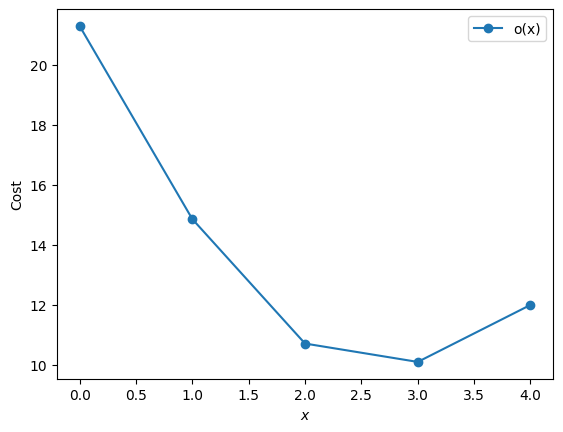

In [201]:
# NOTE index i indicates the wind turbines produce 'i' units of power (implicitly, x=d-i)
exp_vals = optimizer.brute_force_wind_demand_expectation_values() # for each value of d-x, compute the expectation value
bruteforce_vals = [optimizer.gas_costs[0]*x + exp_vals[d-x] for x in range(d+1)] # for each x value compute the objective function

plt.xlabel(r'$x$')
plt.ylabel(r'Cost')
plt.plot(bruteforce_vals, '-o', label='o(x)')
plt.legend()
plt.show()

# Check Digitized Quantum Annealing
Use the adiabatic evolution circuit to prepare the per-scenario optimized wavefunction:

$$ |x\rangle\sum_{\xi_i} \sqrt{p(\xi_i)} |y_i^*, \xi_i\rangle = \lim_{T->\infty} \Big[\prod_{t=0}^{T} e^{-ia(t/T)H_M}e^{-ib(t/T)H_C} \Big] V_S V_\xi |x,0,0\rangle$$

To better encode the problem on a quantum computer, we elect to re-write the _second state_ objective function as 
$$ Q(x,\xi) = \min_y \sum_{i=0}^{n_y-1} c_{y,i}y_i\xi_i + c_ry_i(1-\xi_i)$$
$$ x+\sum_{i=0}^{n_y-1} y_i = d$$
To see the circuit implementation of the cost and mixer Hamiltonians, look at functions `cost_operator` and `demand_constraint_preserving_mixer` in the `BinaryNestedOperator` class.

## Fixed wind output
First, we fix total wind output to $i=2$ to assert that this wavefunction is correct. First we construct the circuit with `adiabatic_evolution_circuit`, then we run the experiment to construct a statevector.

To visualize what the algorithm does, we can see that, each scenario (the first 4 qubits) demarkates a different wavefunction on the second register 4 qubits (decision variables). We can also plot this: notice how the rightmost (cheapest) qubits get the $1$ states whenever possible. Also observe how the second-stage decision converges to a delta function at the best 'choice' as `t` increases. 

Finally, we can compare this value with the expectation value computed classically.

In [181]:
t = 4
tsteps = 4
w_d = 2

# this norm parameter is a divisor for all cost function terms; 
# play with it to change which parameters are more important to satisfy.
Uopt = optimizer.adiabatic_evolution_circuit(w_d, time=t, time_steps=tsteps, norm=5.) 
#print(Uopt)

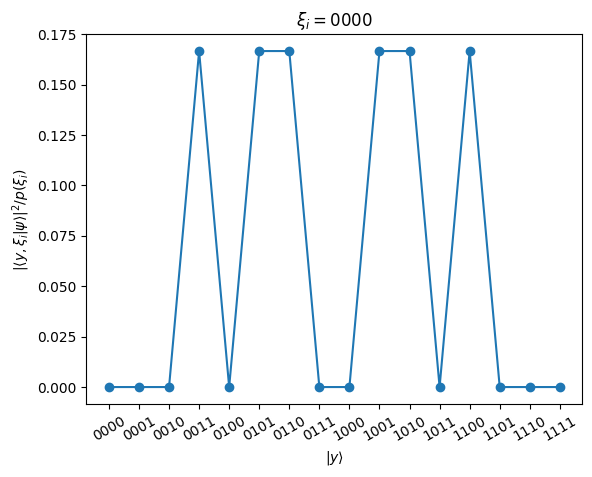

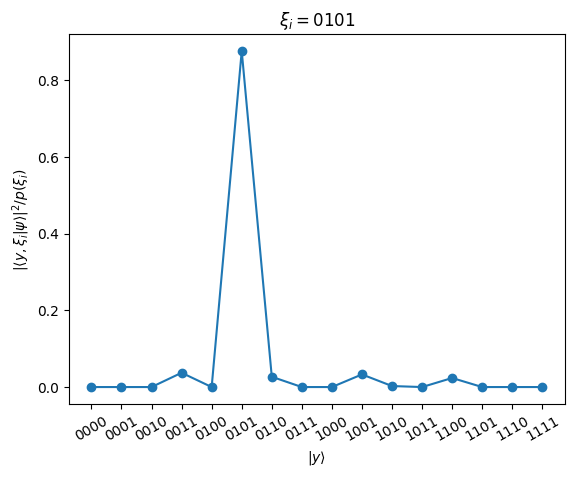

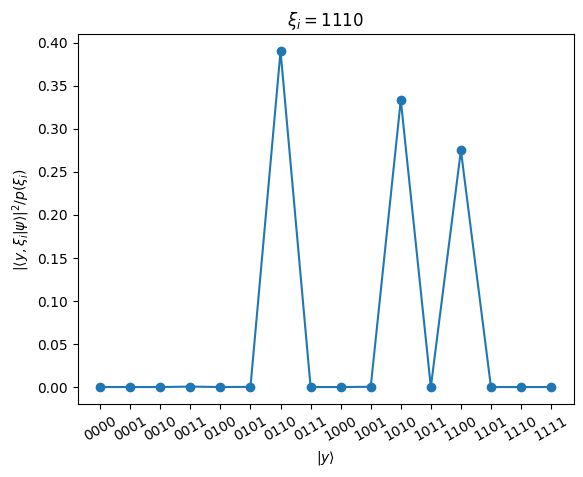

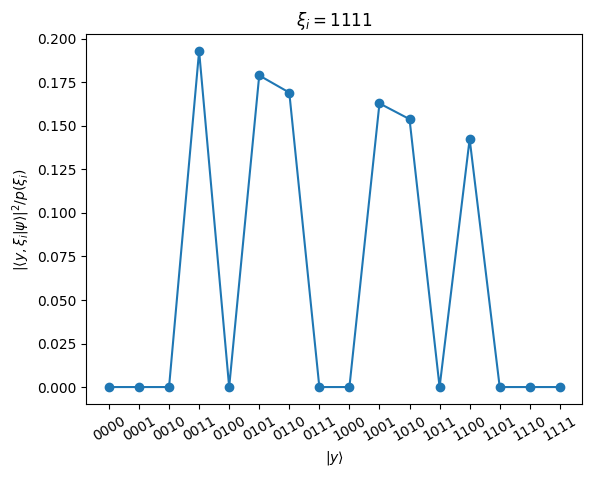

In [182]:
# get a dictionary of bitstring -> probability
sv = Statevector.from_label('0'*(n_y+n_xi))
sv = sv.evolve(Uopt)
results = sv.probabilities_dict()

# create a dictionary of pdf scenario -> decision register
decisions = {}
str_scenarios = []
for scenario,pr in pdf.items():
    s = ''.join([str(x) for x in scenario])
    str_scenarios.append(s)
    decisions[s] = {}
    for bstr,pr1 in results.items():
        if bstr[:n_xi] == s:
            decisions[s][bstr[n_xi:]] = pr1/pr

            
# for each scenario, plot the objective function surface
xvals = [('{0:0' + str(n_y) + 'b}').format(s) for s in range(2**n_y)] # make a list of all possible |y> bitstrings
# just choose a few scenarios to look at the objective function surface
scenarios_plots = ['0000', '0101', '1110', '1111']
for bstr in scenarios_plots:
    yvals = [decisions[bstr][bstr2] if bstr2 in decisions[bstr].keys() else 0. for bstr2 in xvals]
    plt.plot(xvals, yvals, '-o')
    # plot parameters
    plt.xticks(rotation=30, ha='center')
    plt.xlabel(r'$|y\rangle$')
    plt.ylabel(r'$|\langle y,\xi_i | \psi \rangle|^2 / p(\xi_i)$')
    plt.title(r'$\xi_i=${}'.format(bstr))
    plt.show()


In [183]:
exp_qc = optimizer.process_expectation_value_optimizer(w_d, results)
print('Quantum observable vs. classical expectation value:\n', exp_qc, exp_vals[w_d])

Quantum observable vs. classical expectation value:
 5.314403034567589 4.712500000000002


In [184]:
# We have a few control variables here: time, time steps, and normalization. Use 
#   this cell to play with them and see if you can beat the convergence listed above

# Quantum Amplitude Estimation
Now we set `m` measurement qubits, and choose the oracle $\mathcal{F}_{\sin}$, which will induce some systematic error but will still be very fast. We also must choose a normalization $\text{norm}$ for the oracle such that $r*d/\text{norm}=1$. We will do this again with wind demand $=2$. We will also use the same adiabatic evolution parameters from the last section

In [192]:
# parameters from the last section
t = 4
tsteps = 4
w_d = 2
Uopt = optimizer.adiabatic_evolution_circuit(w_d, time=t, time_steps=tsteps, norm=5.) 
Uopt_inverse = Uopt.inverse() # we also need the inverse of this operator

# create the oracles
c = 1 # legacy parameter, leave at 1
norm = w_d * c_r
oracle = optimizer.single_oracle_sin_inconstraint(c, norm, inverse=False)
oracle_inverse = optimizer.single_oracle_sin_inconstraint(c, norm, inverse=True)

# create the QAE circuit
m = 4
circuit = optimizer.implemented_qae(Uopt, oracle, Uopt_inverse, oracle_inverse, m, norm)
print(circuit)

        ┌───┐                     ┌──────┐┌────────────┐             »
 q_0: ──┤ H ├──────────────■──────┤0     ├┤0           ├──────■──────»
        ├───┤              │      │      ││            │      │      »
 q_1: ──┤ H ├──────────────┼──────┤      ├┤            ├──────┼──────»
        ├───┤              │      │      ││            │      │      »
 q_2: ──┤ H ├──────────────┼──────┤      ├┤            ├──────┼──────»
        ├───┤              │      │      ││            │      │      »
 q_3: ──┤ H ├──────────────┼──────┤      ├┤            ├──────┼──────»
      ┌─┴───┴─┐┌────┐      │      │      ││            │┌───┐ │ ┌───┐»
 q_4: ┤0      ├┤0   ├──────┼──────┤1     ├┤1           ├┤ X ├─■─┤ X ├»
      │       ││    │      │      │      ││            │├───┤ │ ├───┤»
 q_5: ┤1      ├┤1   ├──────┼──────┤2     ├┤2           ├┤ X ├─■─┤ X ├»
      │       ││    │      │      │      ││  c_Uopt_dg │├───┤ │ ├───┤»
 q_6: ┤2      ├┤2   ├──────┼──────┤3 c_F ├┤3           ├┤ X ├─■─┤ X ├»
      

In [193]:
# run the circuit
sv = Statevector.from_label('0'*(n_y + n_xi + m + 1))
sv = sv.evolve(circuit)

In [198]:
# measure the first m qubits
nmeas = 1 # how many times do we repeat the experiment?
results = sv.sample_counts(nmeas, qargs=list(range(m)))

# post process the results
for key,value in results.items():
    # get the amplitude
    amp = np.sin(int(key,2)*np.pi/2**m)**2 
    print('Expected value function estimate:', amp*norm)
    
print("True function", exp_vals[w_d])

Expected value function estimate: 6.173165676349102
True function 4.712500000000002


In [191]:
# Given the above cell, try increasing the number of measurements and averaging over the produced estimates.
#    Keep in mind that this can only be done a CONSTANT number of times (in the asymptotic sense)
#    in order to preserve the quadratic speedup afforded by quantum amplitude estimation

In [197]:
# Try changing the number of sample qubits - each increment in m is a new circuit with twice the length 
#    of the previous m (and thus exponential), so keep in mind that m is quite expensive

# All together
Given the above two sections, try to reproduce the plot of the true objective function using the quantum code. You will use the same classical function to compute the first-stage cost $f(x)$ for each candidate $x$. I have copied the classical code to here for conveniece. When finished, the plots should be a good qualitative match.

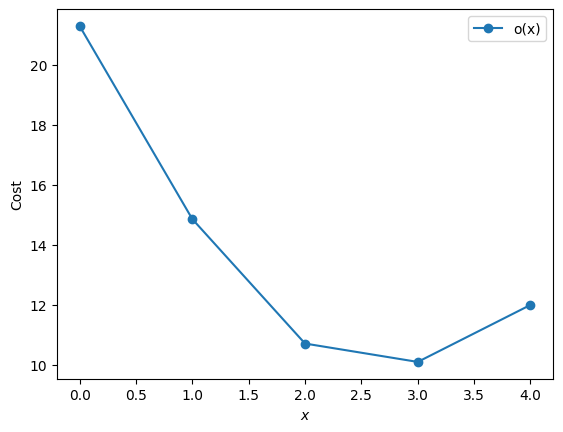

In [202]:
plt.xlabel(r'$x$')
plt.ylabel(r'Cost')
plt.plot(bruteforce_vals, '-o', label='o(x)')
plt.legend()
plt.show()